# Ion Liquid Selection and Reactor-Separator Network Optimization

This script solves a QUBO model for the discrete part of ionic liquid selection and process network optimization problem using simulated annealing, quantum annealing (dwave), and entropy computing (dirac-1). 
The IP formulation of the discrete part of the original problem is documented in "ilrs_discrete_IP.jl" file. In the same file, the JuMP model is converted to a QUBO model using QUBO.jl package, and the resulting QUBO model is exported for use in Python environment.  

The problem involves selecting ionic liquids for a reactor-separator network design, where the goal is to minimize the total cost while satisfying various flow constraints. It is formulated as an integer programming to select ionic liquids and reactor-separator network based on various logical constraints, formulated as linear and/or quadratic constraints. See the "ilrs_discrete_IP.jl" file for the details of the model and Gurobi solver. 

The original MINLP problem is adapted from the following source:

    Iftakher, A., & Hasan, M. M. F. (2024). Exploring quantum optimization for computer-aided Molecular and Process Design. Systems and Control Transactions, 3, 292–299. https://psecommunity.org/LAPSE:2024.1540


In [4]:
import sys
sys.path.append('..')  # Adds the parent directory (il-rxtor-sep-opt) to the path

import pandas as pd
from ilrs_common import *
from ilrs_plotting import *


In [2]:
import os

# Set the D-Wave API token
os.environ["DWAVE_API_TOKEN"] = "your-api-token"

# DATA COLLECTION 
## Import QUBO model and solve using different methods 

In [3]:
# Import Q matrix and scalars from the Julia export (QUBO model)
Q_filepath = "./julia_exports/Q_matrix_1.csv"
L_filepath = "./julia_exports/L_vector_1.csv"
scalars_filepath = "./julia_exports/scalars_1.csv"

Q, beta = import_from_julia(scalars_filepath, Q_filepath, L_filepath)

In [5]:
# ================ DWave / QA ==========================
# Solve the QUBO model using Dwave quantum annealer 
# Execution time includes embedding time + solving time 
DWaveSamples, t_qa = solve_qa_dwave(Q, beta, save=True)

# ================ DWave / QA ==========================
# Solve the QUBO model using Dwave quantum annealer (Advantage 2 system)
# Execution time includes embedding time + solving time 
DWaveSamples_zephyr, t_adv2_qa = solve_qa_dwave(Q, beta, save=True, topology="zephyr")

# Extract the QPU access time from the D-Wave sampleset info, all t values are in seconds. 
t_qa_qpu = DWaveSamples.info['timing']['qpu_access_time'] / 1e6
t_adv2_qa_qpu = DWaveSamples_zephyr.info['timing']['qpu_access_time'] / 1e6

Execution time (QAnn):  1.82491807200131
System name:  Advantage_system4
{'timing': {'qpu_sampling_time': 154480.0, 'qpu_anneal_time_per_sample': 20.0, 'qpu_readout_time_per_sample': 113.9, 'qpu_access_time': 170242.76, 'qpu_access_overhead_time': 855.24, 'qpu_programming_time': 15762.76, 'qpu_delay_time_per_sample': 20.58, 'total_post_processing_time': 1.0, 'post_processing_overhead_time': 1.0}, 'problem_id': 'cdf1d5e5-5c43-4f35-a946-405c1d956ff1', 'embedding_context': {'embedding': {6: (1641, 4043), 5: (4058,), 7: (1476, 4028), 8: (4073,), 9: (1417, 4312), 0: (1567,), 10: (4222, 1462), 11: (1432, 4252), 12: (4341, 4342), 13: (1387, 4311), 1: (4357,), 14: (4281, 1371), 15: (1402, 4266), 16: (4236, 1282), 17: (4191, 4192), 2: (1521, 4223), 18: (4176, 1312), 3: (4237, 4238), 19: (1297, 4206, 4207), 4: (4208,), 20: (1627,), 21: (1492,), 22: (1551,), 23: (1506,), 24: (1176,), 25: (1191,), 26: (4327,), 27: (1447,), 28: (1252,), 29: (1237,), 30: (1356,), 31: (4177,), 32: (1326,), 33: (1341,

In [ ]:
# ================ DWave neal / SA ==========================
simAnnSamples, t_simAnn = solve_sim_annealing(Q, beta, save=True)

# ================ QCI dirac-1 / EQC ==========================
# Solve the QUBO model using QCI dirac-1 / EQC 
file_name = "il-rs_mip_decomp.json"
qci_df, t_qci = solve_eqc_qci(Q, beta, file_name, num_sample=100)

# If jobinfo is needed, use:
# qci_result_df, t_qci, job_body, job_response = solve_eqc_qci(Q, beta, file_name, num_sample=100, jobinfo=True)

# ========== Data Processing ==========
# Use a function to extract energy and probability data only and convert to dataframe
qa_df = sampleset_to_df(DWaveSamples)
qa_adv2_df = sampleset_to_df(DWaveSamples_zephyr)
sa_df = sampleset_to_df(simAnnSamples)

df_names = [ 'DWave_QA','DWave_QA_adv2', 'SimAnnealing', 'QCI_EQC']
df_list = [qa_df, qa_adv2_df, sa_df, qci_df]

Execution time (simAnn):  0.3511617183685303


## DATA ANALYSIS 

These results may be collected from DATA COLLECTION section or imported from saved files. 

In [7]:
# ========== Get saved results from JSON files for data analysis ==========
import_dir = './result_raw'

# Simulated annealing results
sa_path = os.path.join(import_dir, 'SA_results_20260114_163501.json')
sa_df, t_sa = import_sampleset(sa_path)

# qa_path = os.path.join(import_dir, 'Dwave_QA_results_sampleset.json')
qa_path = os.path.join(import_dir, 'Dwave_QA_results_20260626_161207.json')
(qa_df, t_qa), t_qa_qpu = import_sampleset(qa_path, qa=True)
# t_qa_qpu is quantum time, t_qa is total execution time

qa_adv2_path = os.path.join(import_dir, 'Dwave_QA_results_20260626_161210.json')
(qa_adv2_df, t_adv2_qa), t_adv2_qa_qpu = import_sampleset(qa_adv2_path, qa=True)

# QCI results
qci_path = os.path.join(import_dir, 'QCI_EQC_results.json')
qci_result_df, t_qci = import_sampleset(qci_path)



In [8]:
# ========== Calculate time-to-solution (tts) ==========
feas_ub = 57        # upper bound for feasible solution, taken from Gurobi result
opt_ub = 19.1       # upper bound for optimal solution, taken from Gurobi result

# Calculate the time to solution for the feasible solutions (tts_f) and optimal solutions (tts_opt)
sa_tts_f = calculate_tts(sa_df, t_sa, feas_ub)
sa_tts_opt = calculate_tts(sa_df, t_sa, opt_ub)
qci_tts_f = calculate_tts(qci_result_df, t_qci, feas_ub)
qci_tts_opt = calculate_tts(qci_result_df, t_qci, opt_ub)
dwave_total_tts_f = calculate_tts(qa_df, t_qa, feas_ub)
dwave_total_tts_opt = calculate_tts(qa_df, t_qa, opt_ub)
dwave_qc_tts_f = calculate_tts(qa_df, t_qa_qpu, feas_ub)
dwave_qc_tts_opt = calculate_tts(qa_df, t_qa_qpu, opt_ub)

# ========== Additional QA results from D-Wave Advantage 2 system ==========
dwave_total_tts_f_adv2 = calculate_tts(qa_adv2_df, t_adv2_qa, feas_ub)
dwave_total_tts_opt_adv2 = calculate_tts(qa_adv2_df, t_adv2_qa, opt_ub)
dwave_qc_tts_f_adv2 = calculate_tts(qa_adv2_df, t_adv2_qa_qpu, feas_ub)
dwave_qc_tts_opt_adv2 = calculate_tts(qa_adv2_df, t_adv2_qa_qpu, opt_ub)

tts_feas = {
    'SA': sa_tts_f, 
    'QA-DWAVE_qpu': dwave_qc_tts_f, 
    'QA-DWAVE_total': dwave_total_tts_f, 
    'QA-DWAVE2_qpu': dwave_qc_tts_f_adv2, 
    'QA-DWAVE2_total': dwave_total_tts_f_adv2, 
    'EQC-QCI_qpu': qci_tts_f
    }

tts_opt = {
    'SA': sa_tts_opt, 
    'QA-DWAVE_qpu': dwave_qc_tts_opt, 
    'QA-DWAVE_total': dwave_total_tts_opt, 
    'QA-DWAVE2_qpu': dwave_qc_tts_opt_adv2, 
    'QA-DWAVE2_total': dwave_total_tts_opt_adv2, 
    'EQC-QCI_qpu': qci_tts_opt
    }
    
# Format each value to 1 decimal place
formatted_tts_feas = {k: f"{v:.2f}" for k, v in tts_feas.items()}
formatted_tts_opt = {k: f"{v:.2f}" for k, v in tts_opt.items()}

df_tts = pd.DataFrame({
    'TTS_feas': formatted_tts_feas,
    'TTS_opt': formatted_tts_opt
})
print(df_tts)           


Probability of solution <= 57 : 0.946
Time to solution <= 57 : 0.5364441878299941
Probability of solution <= 19.1 : 0.007
Time to solution <= 19.1 : 222.8958992466225
Probability of solution <= 57 : 1.0
Time to solution <= 57 : 37.0
Probability of solution <= 19.1 : 0.13
Time to solution <= 19.1 : 1223.529853779226
Probability of solution <= 57 : 0.436
Time to solution <= 57 : 14.67442503808839
Probability of solution <= 19.1 : 0.001
Time to solution <= 19.1 : 8399.855567214187
Probability of solution <= 57 : 0.436
Time to solution <= 57 : 1.368946178037235
Probability of solution <= 19.1 : 0.001
Time to solution <= 19.1 : 783.6048189251984
Probability of solution <= 57 : 0.962
Time to solution <= 57 : 3.2908433171721314
Probability of solution <= 19.1 : 0.013
Time to solution <= 19.1 : 822.4239343964647
Probability of solution <= 57 : 0.962
Time to solution <= 57 : 0.2348796980554213
Probability of solution <= 19.1 : 0.013
Time to solution <= 19.1 : 58.69944776057815
                T

In [9]:
# ========== Plot the results of the optimization ==========
# # combine the probability values that have energy values (infeasible solutions) that are > feas_ub to one value
# simAnn_df_red = sum_infeas_soln(sa_df, feas_ub)
# dwave_df_red = sum_infeas_soln(qa_df, feas_ub)

# Add the Gurobi results to the graph 
gurobi_result = sa_df.index[0]

# Plot only feasible solutions
dwave_df_feas = qa_df[qa_df.index < feas_ub] 
simAnn_df_feas = sa_df[sa_df.index < feas_ub]

# # Plot the results of the optimization
# df_list_feas = [simAnn_df_feas, dwave_df_feas, qci_result_df]  
# df_names = ['Simulated Annealing', 'Quantum Annealing', 'Entropy Quantum Computing'] 
# df_colors = ['#4E5D6C', '#C9A66B', '#6B7C59']

# fig_1 = plot_multibar_graph_discrete(df_list_feas, df_names, df_colors, feas_ub, vertical_line=gurobi_result)


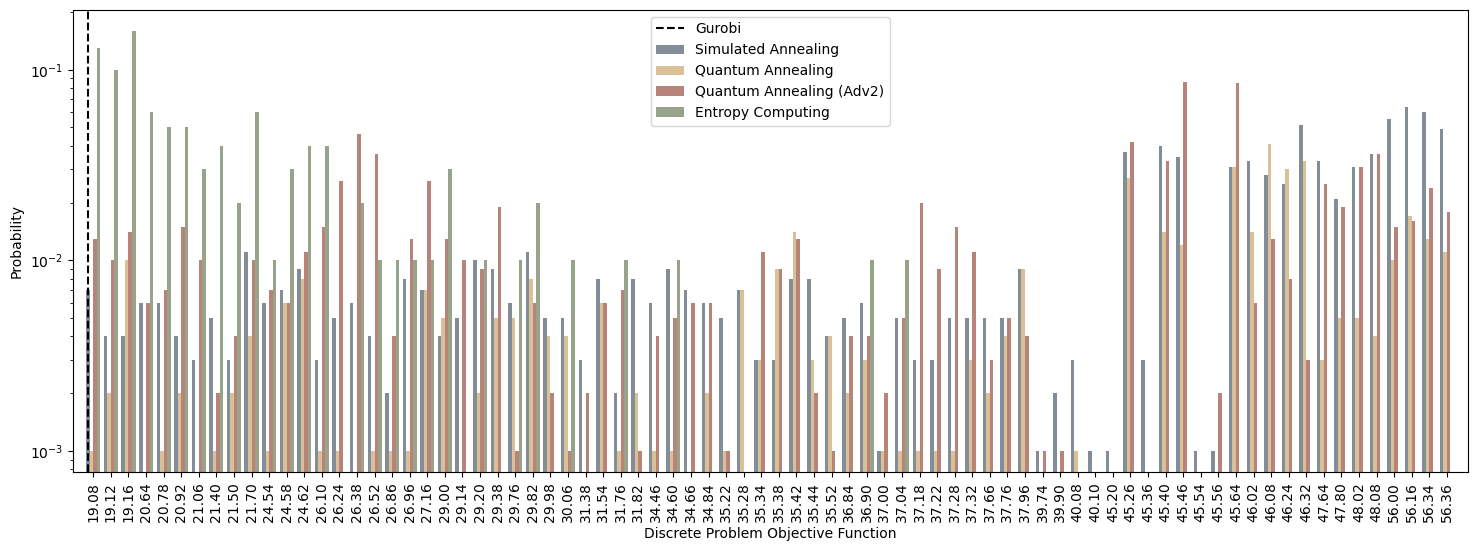

In [10]:
# Plot the results of the optimization
df_names_2 = ['Simulated Annealing', 'Quantum Annealing', 'Quantum Annealing (Adv2)', 'Entropy Computing'] 
df_colors_2 = ['#4E5D6C', '#C9A66B', '#9B4F3F', '#6B7C59']

# Plot only feasible solutions
dwave_df_adv2_feas = qa_adv2_df[qa_adv2_df.index < feas_ub]

# Plot the results of the optimization
df_list_feas_2 = [simAnn_df_feas, dwave_df_feas, dwave_df_adv2_feas, qci_result_df]  

fig_2 = plot_multibar_graph_discrete(df_list_feas_2, df_names_2, df_colors_2, feas_ub, vertical_line=gurobi_result)


In [11]:
fig_2.savefig('../../images/260115_ilrs_feas.svg', bbox_inches="tight", facecolor="white")

In [11]:
# ========== Compare Energy Levels Across Dataframes ==========
from ilrs_helper_fn import compare_dataframe_energy_levels

# Prepare dataframes and names
df_list_feas = [simAnn_df_feas, dwave_df_feas, dwave_df_adv2_feas, qci_result_df]
df_names_feas = ['SA', 'QA_adv1', 'QA_adv2', 'QCI']

# Compare energy levels (rounding to 2 decimals, same as plotting function)
comparison_results = compare_dataframe_energy_levels(
    df_list_feas, 
    df_names_feas, 
    round_decimals=2,
    energy_threshold=feas_ub,  # Only consider feasible solutions
    display=True
)


ENERGY LEVEL COMPARISON SUMMARY

Summary Statistics:
Dataframe  Total_Energy_Levels  Unique_Energy_Levels  Missing_Energy_Levels  Min_Energy  Max_Energy  Best_Energy
       SA                   78                     4                      0       19.08       56.36        19.08
  QA_adv1                   65                     0                     13       19.08       56.36        19.08
  QA_adv2                   72                     0                      6       19.08       56.36        19.08
      QCI                   28                     0                     50       19.08       37.04        19.08

MISSING ENERGY LEVELS BY DATAFRAME

SA - No missing energy levels (contains all energy levels from other dataframes)

QA_adv1 - Missing 13 energy level(s):
  20.64 (found in: SA, QA_adv2, QCI)
  21.06 (found in: SA, QA_adv2, QCI)
  26.38 (found in: SA, QA_adv2, QCI)
  29.14 (found in: SA, QA_adv2)
  31.38 (found in: SA, QA_adv2)
  34.66 (found in: SA, QA_adv2)
  39.74 (found in:

In [ ]:
# ================ Measure Embedding Times ==========================
# Import the helper function for measuring embedding times
from ilrs_helper_fn import measure_embedding_times_for_samplers

# Measure embedding time for different topologies
# Example: measure for pegasus topology (Advantage 4.1)
embedding_result_pegasus = measure_embedding_times_for_samplers(Q, beta, "pegasus", trials=30)
print("Pegasus (Advantage 4.1) embedding time:", embedding_result_pegasus, '\n')

# Example: measure for zephyr topology (Advantage 2)
embedding_result_zephyr = measure_embedding_times_for_samplers(Q, beta, "zephyr", trials=30)
print("Zephyr (Advantage 2) embedding time:", embedding_result_zephyr)

Pegasus (Advantage 4.1) embedding time: {'trials': 30, 'successes': 30, 'failures': 0, 'median_s': 0.10624624599950039, 'p90_s': 0.13554771700000856, 'min_s': 0.07983682700069039, 'max_s': 0.14983140299955267}
Zephyr (Advantage 2) embedding time: {'trials': 30, 'successes': 30, 'failures': 0, 'median_s': 0.0973329914995702, 'p90_s': 0.11829097699956037, 'min_s': 0.06760706500062952, 'max_s': 0.14059832600105437}
